In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt


In [2]:
# 1. Definiamo i percorsi dei due file
file_griglia = 'C:\\Users\\kekko\\Downloads\\Python\\TESI\\CAMELS_data\\Grids_Mcdm_IllustrisTNG_1P_128_z=0.0.npy'
file_aloni = 'C:\\Users\\kekko\\Downloads\\Python\\TESI\\CAMELS_data\\groups_090.hdf5'

# 2. Carichiamo la griglia (Input X)
print("Caricamento griglia 3D...")
grids = np.load(file_griglia)
# Prendiamo la simulazione indice 0 (che corrisponde all'universo fiduciale 1P_1_0)
cubo_3d = grids[0] 
N_GRID = cubo_3d.shape[0] # Sarà 128

# 3. Carichiamo il catalogo (Target Y)
print("Caricamento catalogo aloni...")
with h5py.File(file_aloni, 'r') as f:
    box_size = f['Header'].attrs['BoxSize'] # Dimensione fisica (es. 25000 ckpc/h)
    posizioni = f['Group']['GroupPos'][:]
    masse = f['Group']['GroupMass'][:]
    raggi = f['Group']['Group_R_Mean200'][:]


Caricamento griglia 3D...
Caricamento catalogo aloni...


Verifica Ground Truth: 167 aloni
Proiezione Totale Universo: 20458 aloni


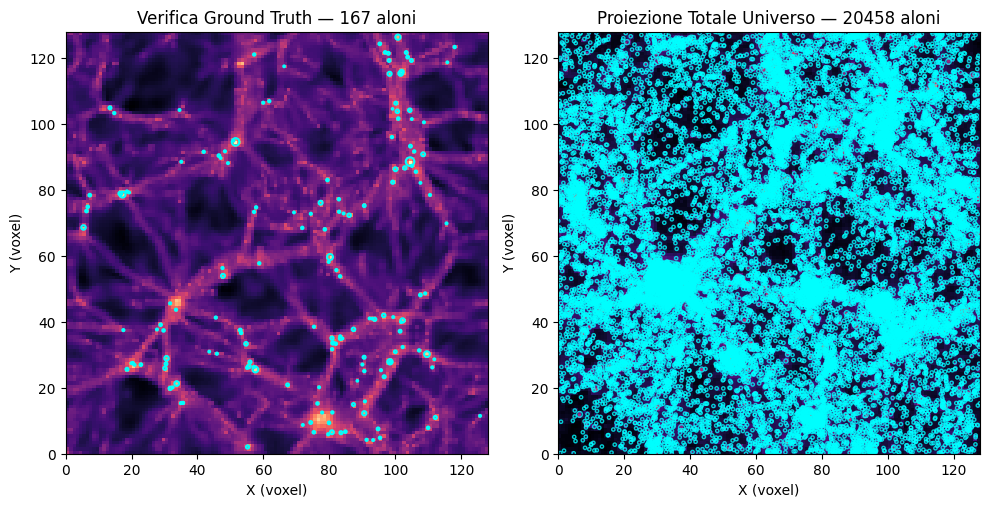

In [3]:
# Parametri fetta
z_min, z_max = 60, 68

# Calcolo proiezioni in una sola riga ciascuna
fetta_log = np.log10(np.mean(cubo_3d[:, :, z_min:z_max], axis=2) + 1e-10)
proj_log  = np.log10(np.mean(cubo_3d, axis=2) + 1e-10)

# Conversione posizioni in coordinate griglia (vettorizzata, niente loop)
xy = (posizioni[:, :2] / box_size) * N_GRID
z_grid = (posizioni[:, 2] / box_size) * N_GRID
r_grid = (raggi / box_size) * N_GRID

# Maschere di filtro
mask_fetta = (z_grid >= z_min) & (z_grid <= z_max) & (masse > 1.0)
mask_proj  = masse > 0.05

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

configs = [
    (axes[0], fetta_log, mask_fetta, r_grid,    1.5, 1.0, "Verifica Ground Truth"),
    (axes[1], proj_log,  mask_proj,  np.maximum(r_grid, 0.5), 1.0, 0.8, "Proiezione Totale Universo"),
]

for ax, img, mask, radii, lw, alpha, title in configs:
    ax.imshow(img.T, cmap='magma', origin='lower', extent=[0, 128, 0, 128])
    for (x, y), r in zip(xy[mask], radii[mask]):
        ax.add_patch(plt.Circle((x, y), r, color='cyan', fill=False, lw=lw, alpha=alpha))
    n = mask.sum()
    ax.set(title=f"{title} — {n} aloni", xlabel="X (voxel)", ylabel="Y (voxel)")
    print(f"{title}: {n} aloni")

plt.tight_layout()
plt.show()

In [4]:
# Caricamento dati
cubo_3d = np.load('C:\\Users\\kekko\\Downloads\\Python\\TESI\\CAMELS_data\\Grids_Mcdm_IllustrisTNG_1P_128_z=0.0.npy')[0]
N_GRID = 128

with h5py.File('C:\\Users\\kekko\\Downloads\\Python\\TESI\\CAMELS_data\\groups_090.hdf5', 'r') as f:
    box_size = f['Header'].attrs['BoxSize']
    posizioni = f['Group']['GroupPos'][:]
    masse     = f['Group']['GroupMass'][:]
    raggi     = f['Group']['Group_R_Mean200'][:]

# Conversione vettorizzata una volta sola
xyz_grid = (posizioni / box_size) * N_GRID          # shape (N, 3)
r_grid   = np.maximum(1.0, (raggi / box_size) * N_GRID)

def mostra_fetta_con_aloni(z_index, massa_minima=1.0, spessore=2.0, ax=None):
    mask = (np.abs(xyz_grid[:, 2] - z_index) <= spessore) & (masse > massa_minima)

    created_ax = ax is None
    if created_ax:
        _, ax = plt.subplots(figsize=(8, 8))

    ax.imshow(np.log10(cubo_3d[:, :, z_index] + 1e-10).T,
              cmap='magma', origin='lower', extent=[0, N_GRID, 0, N_GRID])

    for (x, y), r in zip(xyz_grid[mask, :2], r_grid[mask]):
        ax.add_patch(plt.Circle((x, y), r, color='cyan', fill=False, lw=1.5))

    ax.set_title(f"Fetta Z={z_index} | {mask.sum()} aloni (Massa > {massa_minima})")

    if created_ax:
        plt.show()

    return ax

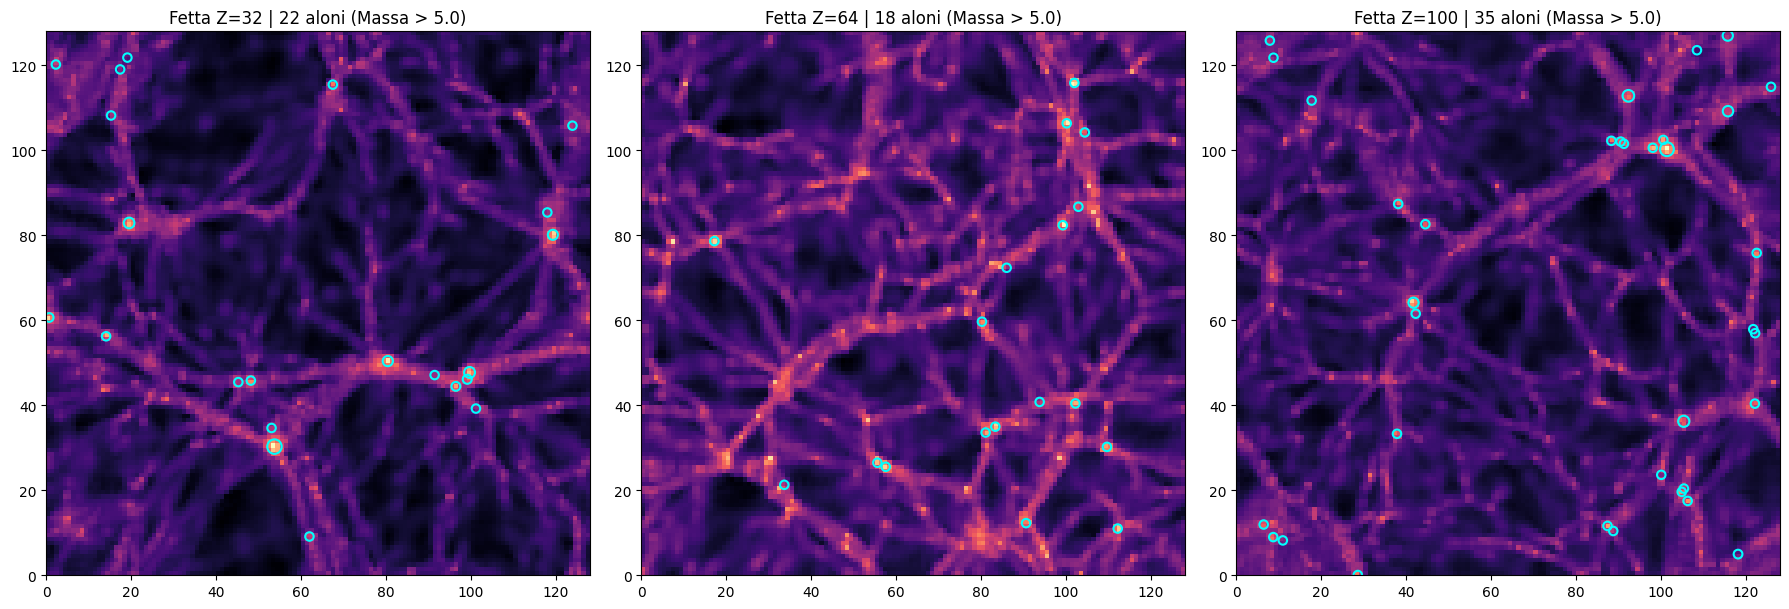

In [5]:
# Mostriamo 3 fette a z=32, 64, 100 con massa minima 5.0
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

mostra_fetta_con_aloni(z_index=32, massa_minima=5.0, ax=axes[0])
mostra_fetta_con_aloni(z_index=64, massa_minima=5.0, ax=axes[1])
mostra_fetta_con_aloni(z_index=100, massa_minima=5.0, ax=axes[2])

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import plotly.graph_objects as go

# 1. Carica il cubo se non lo hai in memoria
grids = np.load('C:\\Users\\kekko\\Downloads\\Python\\TESI\\CAMELS_data\\Grids_Mcdm_IllustrisTNG_1P_128_z=0.0.npy')
cubo_3d = grids[0] 

# Usiamo il logaritmo per far risaltare le strutture
cubo_log = np.log10(cubo_3d + 1e-10)

# 2. Ottimizzazione per il browser
# Per rendere il grafico fluido e interattivo nel notebook, saltiamo 1 pixel ogni 2.
# Il cubo diventa 64x64x64 (abbastanza per vedere perfettamente i filamenti!)
step = 2 
cubo_ridotto = cubo_log[::step, ::step, ::step]

# Creiamo le coordinate X, Y, Z per la griglia
X, Y, Z = np.mgrid[0:128:step, 0:128:step, 0:128:step]

# 3. Filtro di densità
# Se plottassimo tutto l'universo, vedresti solo un "cubo solido" pieno di nebbia.
# Vogliamo rendere trasparente lo spazio vuoto e mostrare solo la materia oscura densa.
# Calcoliamo il 90° percentile (mostriamo solo il 10% dell'universo più denso)
densita_minima_visibile = np.percentile(cubo_ridotto, 90)
densita_massima = np.max(cubo_ridotto)

print("Generazione del rendering 3D... (potrebbe impiegare qualche secondo)")

Generazione del rendering 3D... (potrebbe impiegare qualche secondo)


In [7]:
# 4. Creazione del Grafico 3D (Volume Rendering)
fig = go.Figure(data=go.Volume(
    x=X.flatten(),
    y=Y.flatten(),
    z=Z.flatten(),
    value=cubo_ridotto.flatten(),
    isomin=densita_minima_visibile,
    isomax=densita_massima,
    opacity=0.15,           # Leggera trasparenza per vedere "attraverso" i filamenti
    surface_count=15,       # Numero di "strati" di densità
    colorscale='magma',     # Colore (giallo = aloni molto densi, viola = filamenti)
))

# Abbelliamo il layout
fig.update_layout(
    title="La Cosmic Web in 3D (Materia Oscura)",
    scene=dict(
        xaxis_title='X (voxel)',
        yaxis_title='Y (voxel)',
        zaxis_title='Z (voxel)',
        xaxis=dict(backgroundcolor="black"),
        yaxis=dict(backgroundcolor="black"),
        zaxis=dict(backgroundcolor="black"),
    ),
    paper_bgcolor="black",
    font=dict(color="white"),
    margin=dict(l=0, r=0, b=0, t=40)
)

# Mostra l'immagine interattiva!
fig.show()